---
# Agno 👉 [Learn more](https://www.agno.com/)

---

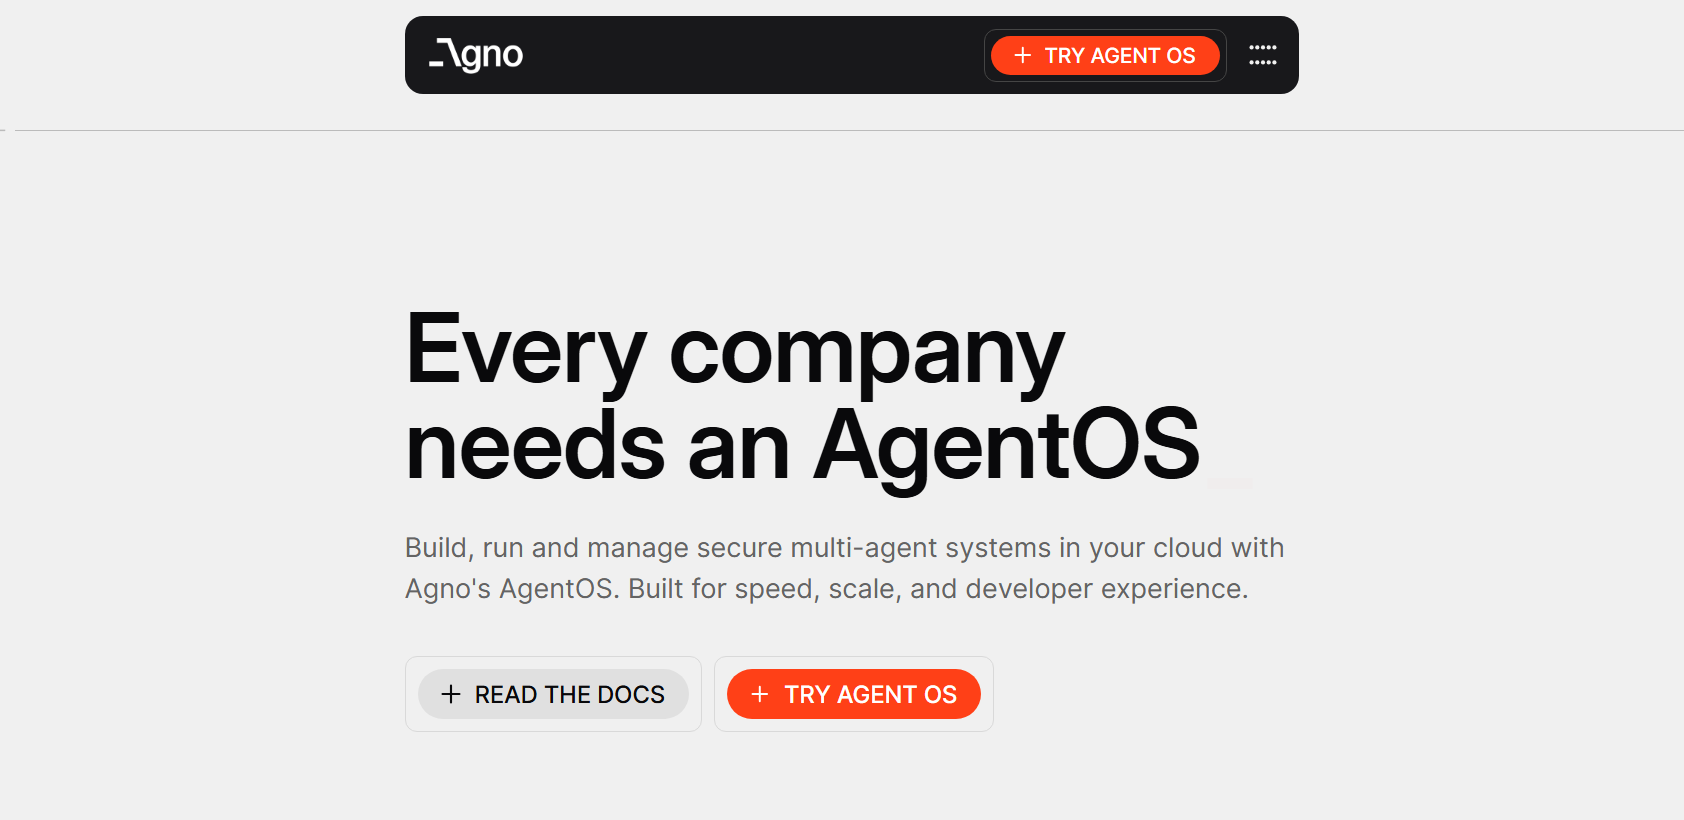

---

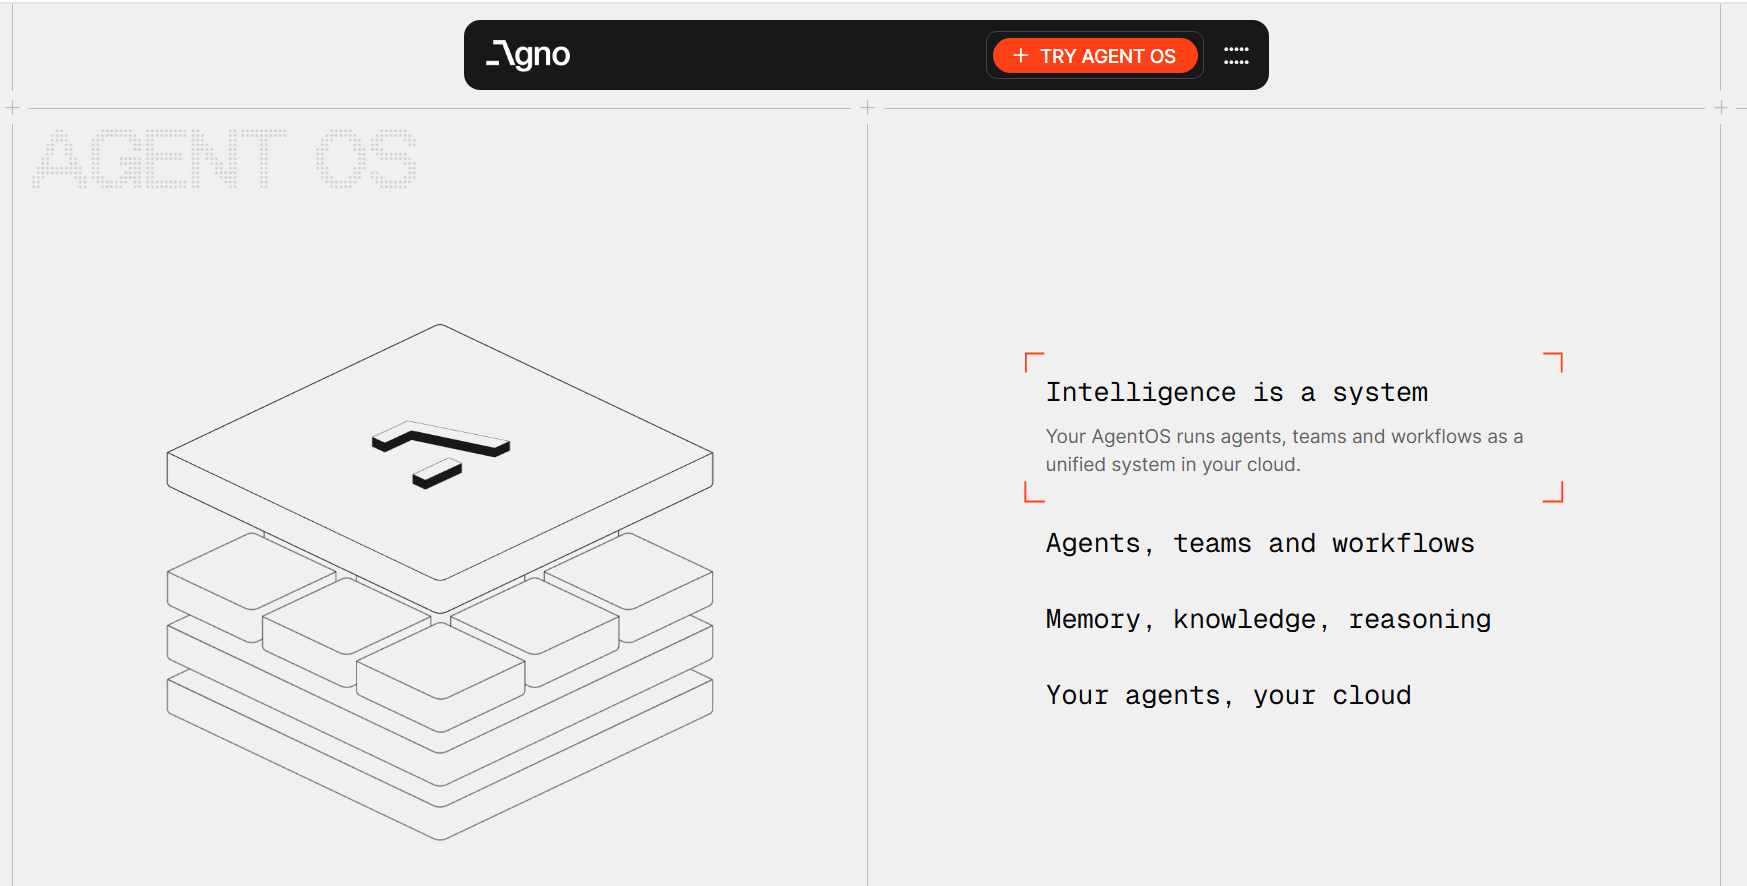 <br> 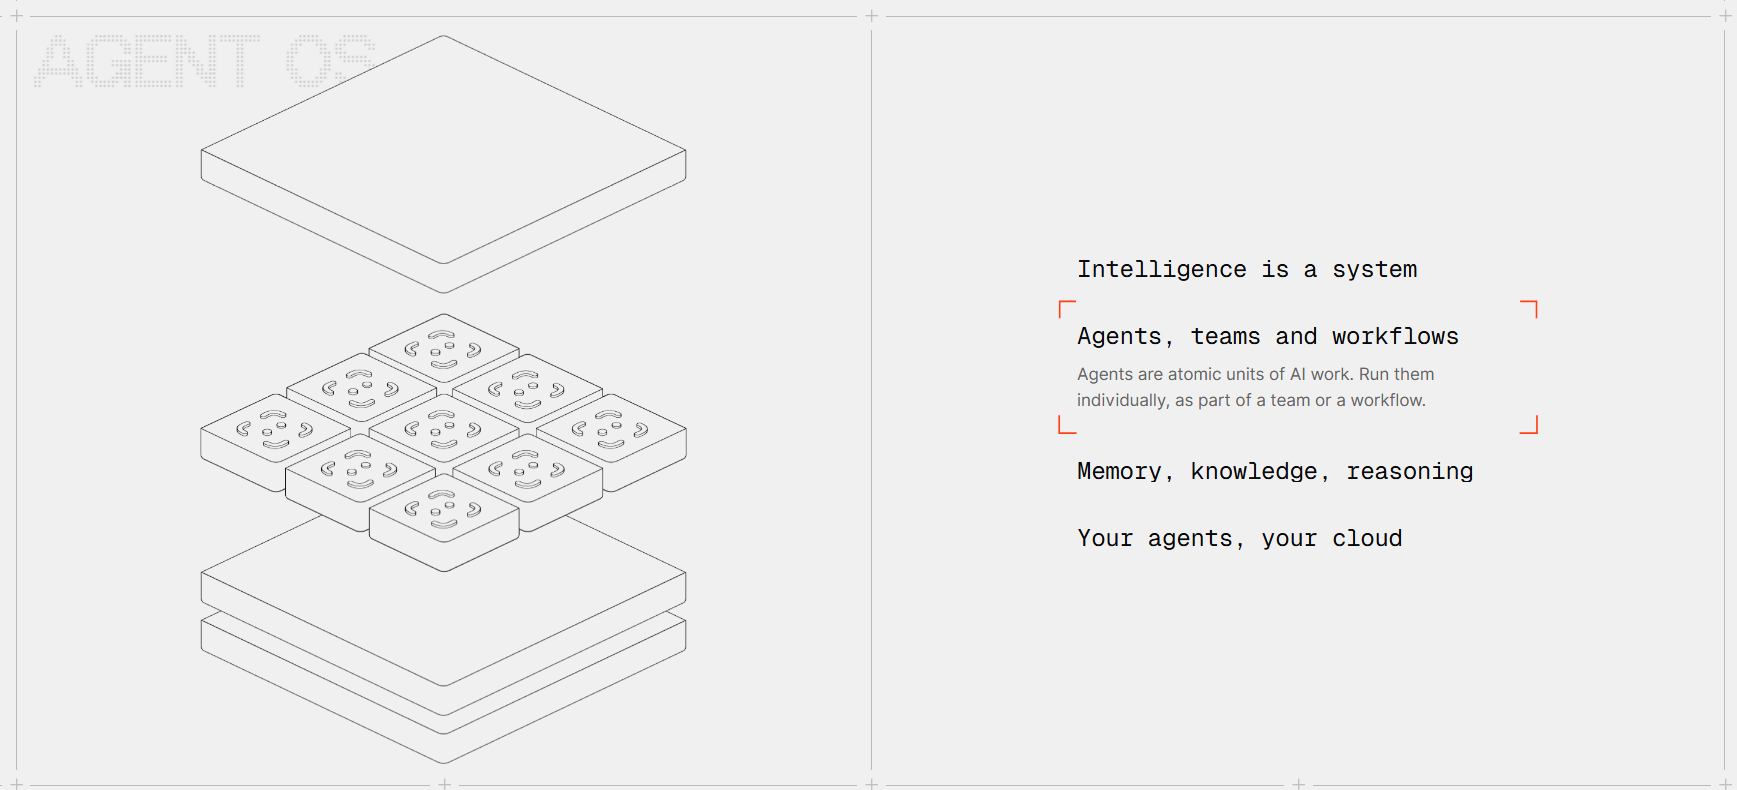 <br> 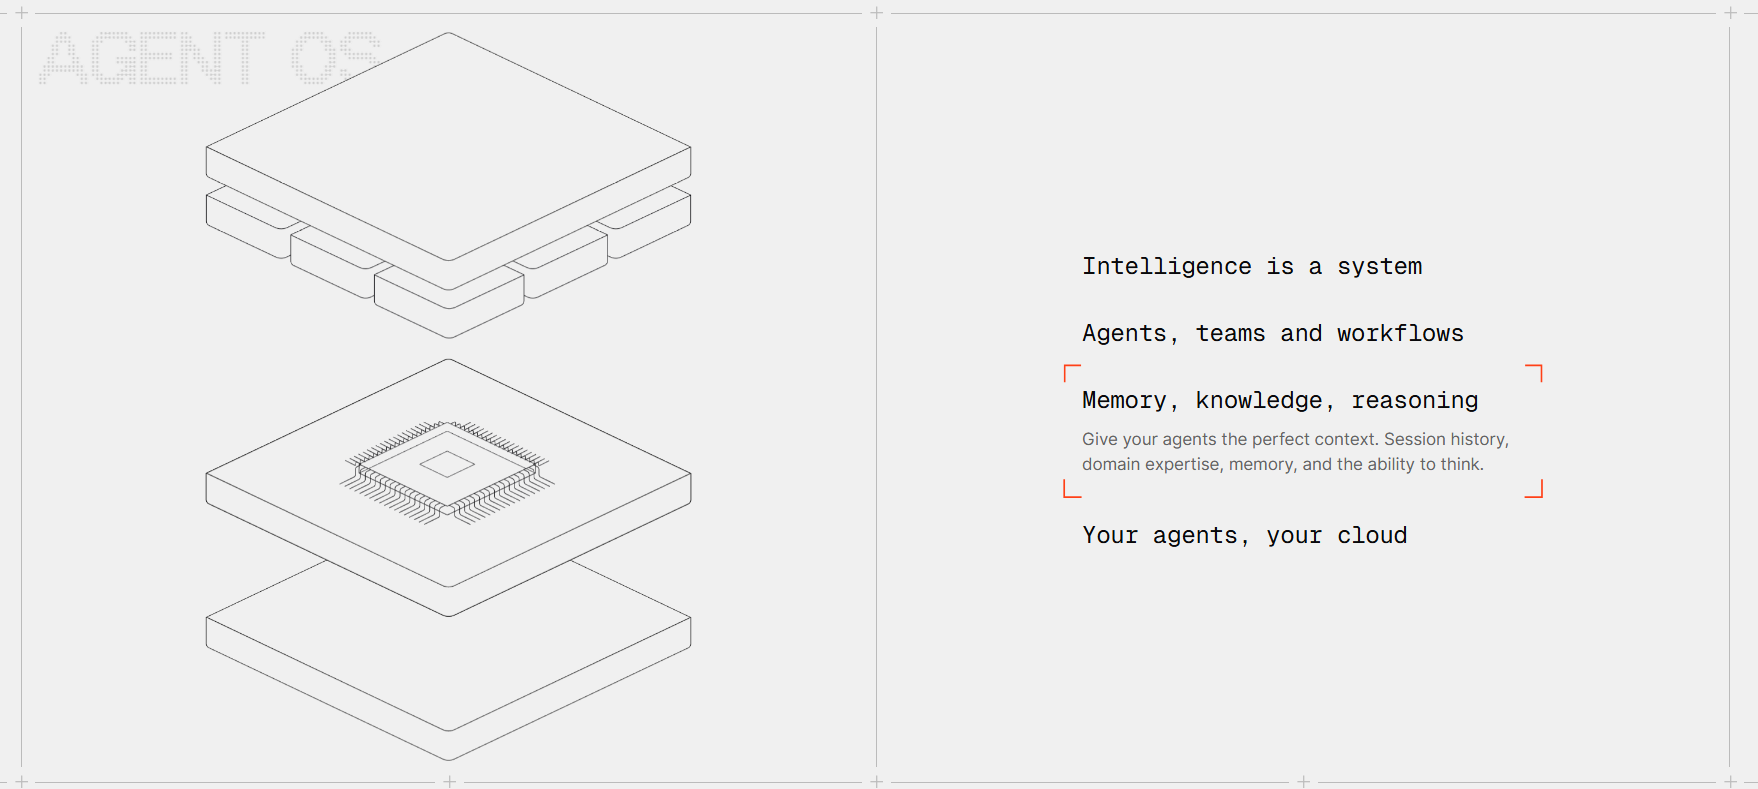 <br> 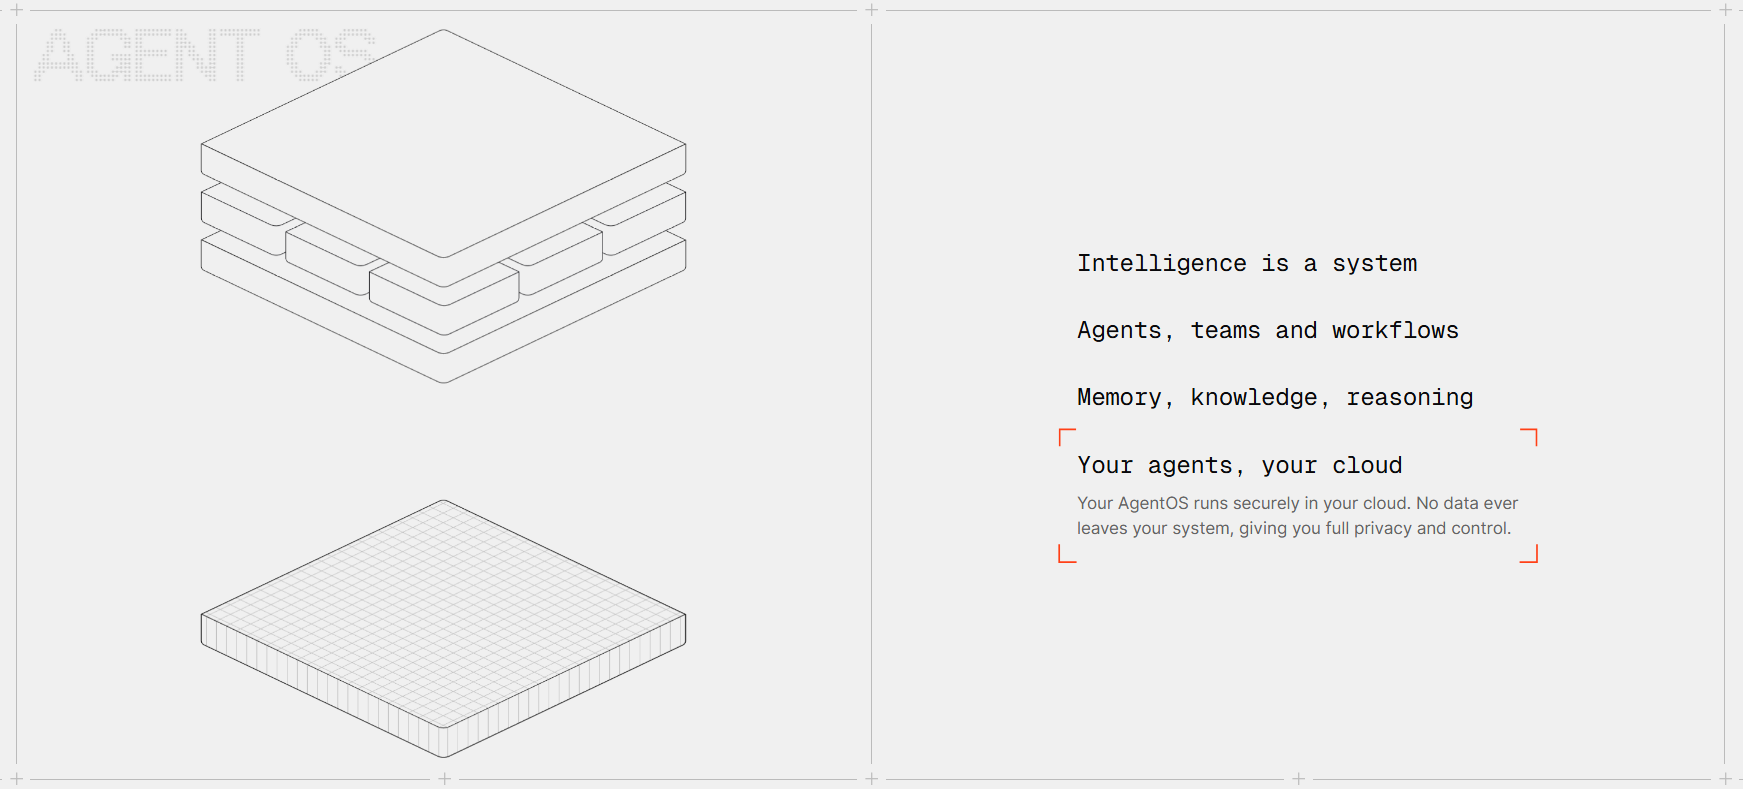 <br>
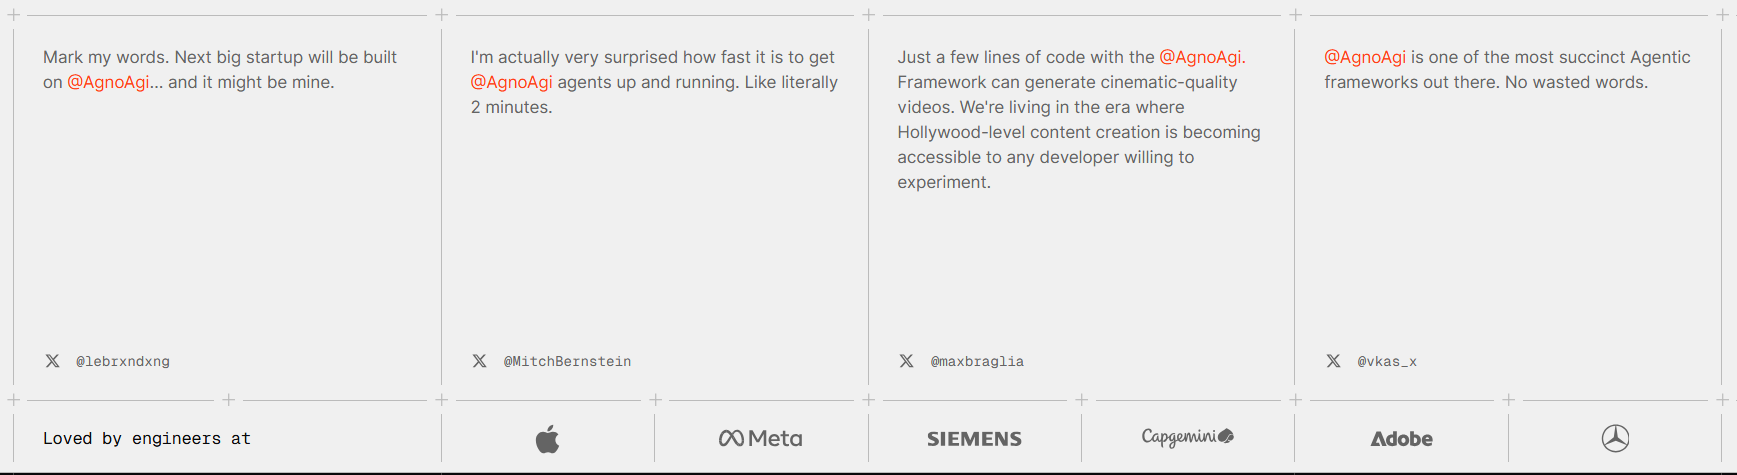


---

## Agno [GitHub](https://github.com/agno-agi/agno)

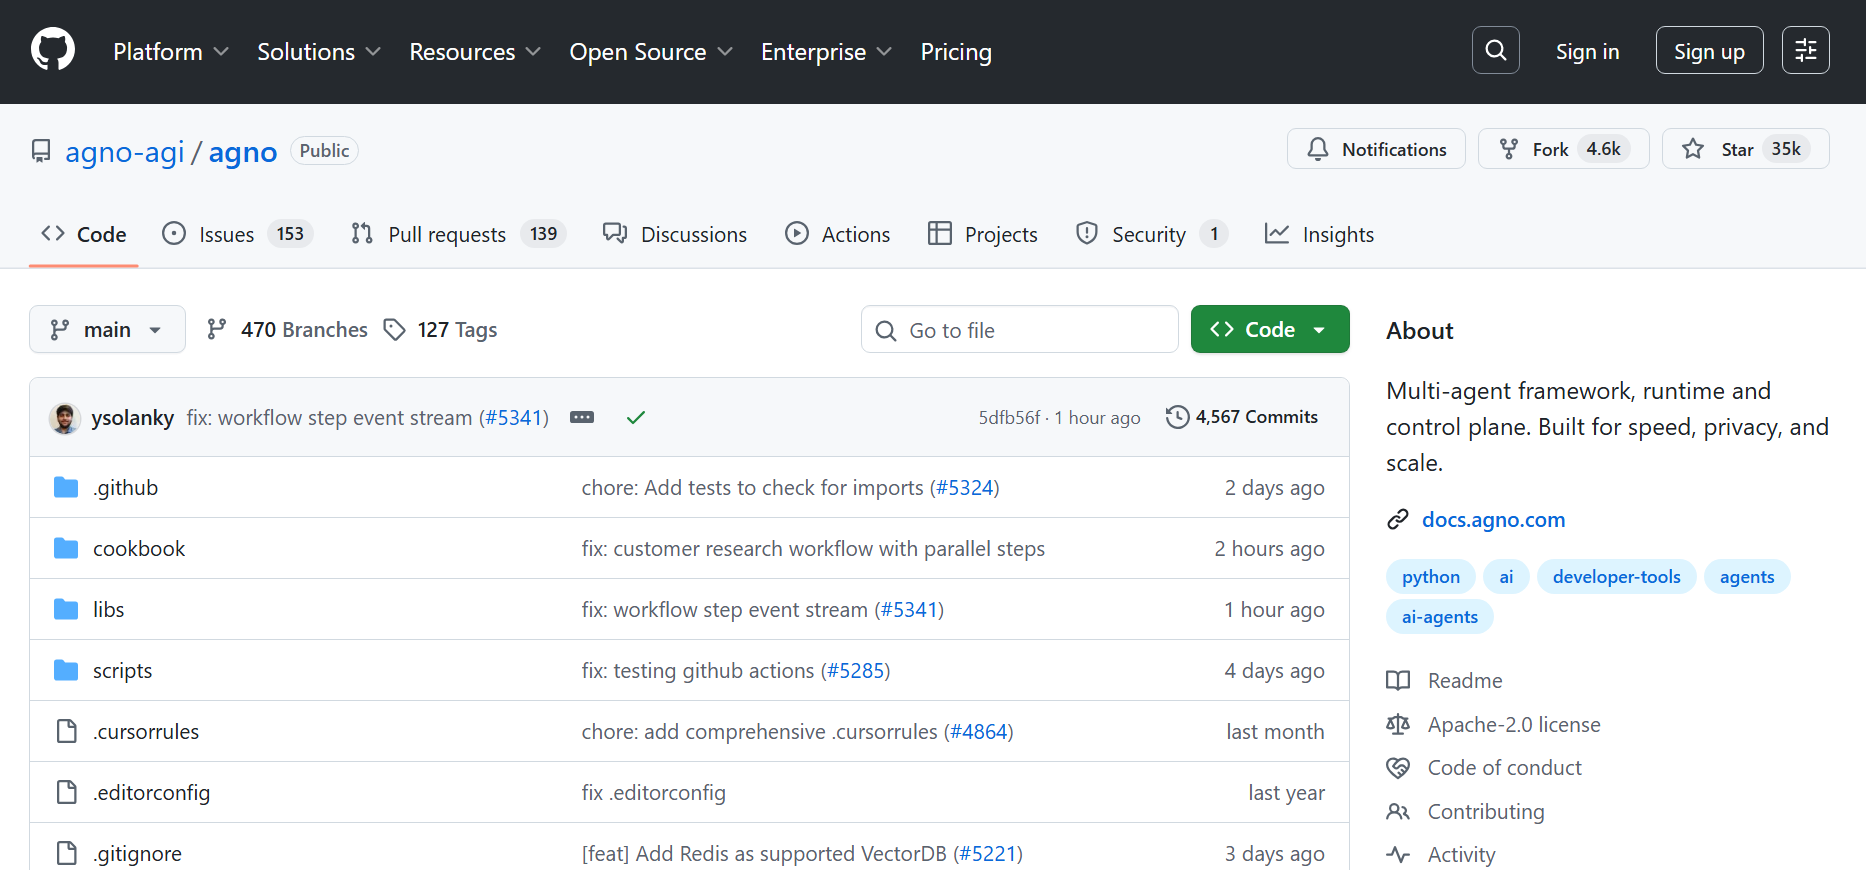 <br> 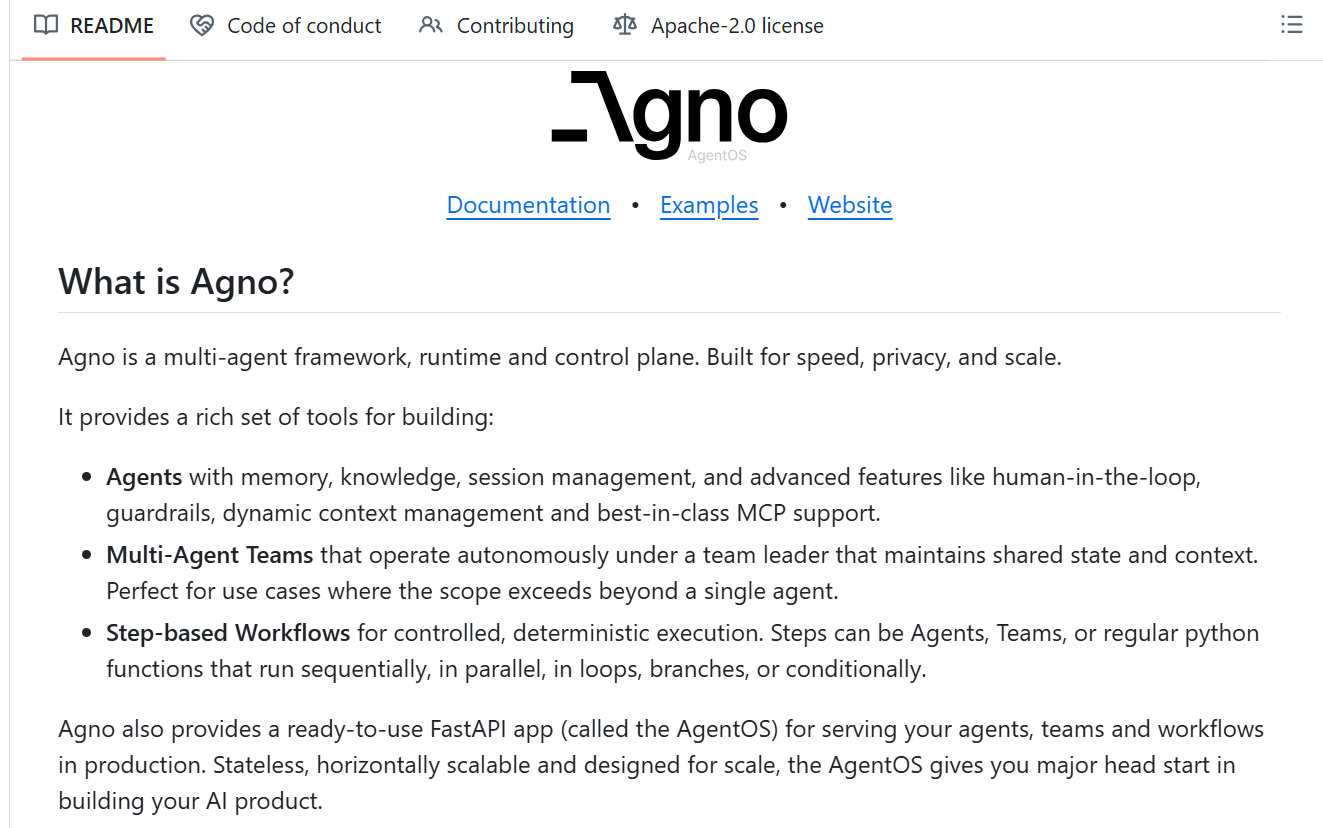 <br> 

----


## [Agno Docs](https://docs.agno.com/introduction)

# What is Agno?

> **Agno is an incredibly fast multi-agent framework, runtime and control plane.**

Use it to build multi-agent systems with memory, knowledge, human in the loop and MCP support. You can orchestrate agents as multi-agent teams (more autonomy) or step-based agentic workflows (more control).

Here’s an example of an Agent that connects to an MCP server, manages conversation state in a database, and is served using a FastAPI application that you can interact with using the [AgentOS UI](https://os.agno.com).

```python agno_agent.py lines theme={null}
from agno.agent import Agent
from agno.db.sqlite import SqliteDb
from agno.models.anthropic import Claude
from agno.os import AgentOS
from agno.tools.mcp import MCPTools

# ************* Create Agent *************
agno_agent = Agent(
    name="Agno Agent",
    model=Claude(id="claude-sonnet-4-5"),
    db=SqliteDb(db_file="agno.db"),
    tools=[MCPTools(transport="streamable-http", url="https://docs.agno.com/mcp")],
    add_history_to_context=True,
    markdown=True,
)

# ************* Create AgentOS *************
agent_os = AgentOS(agents=[agno_agent])
app = agent_os.get_app()

# ************* Run AgentOS *************
if __name__ == "__main__":
    agent_os.serve(app="agno_agent:app", reload=True)
```

## What is the AgentOS?

AgentOS is a high-performance runtime for multi-agent systems. Key features include:

1. **Pre-built FastAPI runtime**: AgentOS ships with a ready-to-use FastAPI app for orchestrating your agents, teams, and workflows. This gives you a major head start in building your AI product.

2. **Integrated Control Plane**: The [AgentOS UI](https://os.agno.com) connects directly to your runtime, letting you test, monitor, and manage your system in real time. This gives you unmatched visibility and control over your system.

3. **Private by Design**: AgentOS runs entirely in your cloud, ensuring complete data privacy. No data ever leaves your system. This is ideal for security-conscious enterprises.

Here's what the [AgentOS UI](https://os.agno.com) looks like in action:

<Frame>
  <video autoPlay muted loop playsInline style={{ borderRadius: "0.5rem", width: "100%", height: "auto" }}>
    <source src="https://mintcdn.com/agno-v2/aEfJPs-hg36UsUPO/videos/agno-agent-chat.mp4?fit=max&auto=format&n=aEfJPs-hg36UsUPO&q=85&s=b8ac56bfb2e9436799299fcafa746d4a" type="video/mp4" data-path="videos/agno-agent-chat.mp4" />
  </video>
</Frame>

## The Complete Agentic Solution

For companies building agents, Agno provides the complete solution:

* The fastest framework for building agents, multi-agent teams and agentic workflows.
* A ready-to-use FastAPI app that gets you building AI products on day one.
* A control plane for testing, monitoring and managing your system.

We bring a novel architecture that no other framework provides, your AgentOS runs securely in your cloud, and the control plane connects directly to it from your browser. You don't need to send data to any external services or pay retention costs, you get complete privacy and control.

## Getting started

If you're new to Agno, follow the [quickstart](/introduction/quickstart) to build your first Agent and run it using the AgentOS.

After that, checkout the [examples gallery](/examples/introduction) and build real-world applications with Agno.

<Tip>
  If you're looking for Agno 1.0 docs, please visit [docs-v1.agno.com](https://docs-v1.agno.com).

  We also have a [migration guide](/how-to/v2-migration) for those coming from Agno 1.0.
</Tip>


---

# Quickstart

> Build and run your first Agent using Agno.

**Agents are AI programs where a language model controls the flow of execution.**

In 10 lines of code, we can build an Agent that uses tools to achieve a task.

```python hackernews_agent.py lines theme={null}
from agno.agent import Agent
from agno.models.anthropic import Claude
from agno.tools.hackernews import HackerNewsTools

agent = Agent(
    model=Claude(id="claude-sonnet-4-5"),
    tools=[HackerNewsTools()],
    markdown=True,
)
agent.print_response("Write a report on trending startups and products.", stream=True)
```

## Build your first Agent

Instead of a toy demo, let's build an Agent that you can extend and build upon. We'll connect our agent to the Agno MCP server, and give it a database to store conversation history and state.

**This is a simple yet complete example that you can extend by connecting to any MCP server**.

```python agno_agent.py lines theme={null}
from agno.agent import Agent
from agno.db.sqlite import SqliteDb
from agno.models.anthropic import Claude
from agno.os import AgentOS
from agno.tools.mcp import MCPTools

# Create the Agent
agno_agent = Agent(
    name="Agno Agent",
    model=Claude(id="claude-sonnet-4-5"),
    # Add a database to the Agent
    db=SqliteDb(db_file="agno.db"),
    # Add the Agno MCP server to the Agent
    tools=[MCPTools(transport="streamable-http", url="https://docs.agno.com/mcp")],
    # Add the previous session history to the context
    add_history_to_context=True,
    markdown=True,
)


# Create the AgentOS
agent_os = AgentOS(agents=[agno_agent])
# Get the FastAPI app for the AgentOS
app = agent_os.get_app()
```

<Check>
  There is an incredible amount of alpha in these 25 lines of code.

  You get a fully functional Agent with memory and state that can access any MCP server. It's served via a FastAPI app with pre-built endpoints that you can use to build your product.
</Check>

## Run your AgentOS

The AgentOS gives us a FastAPI application with ready-to-use API endpoints for serving, monitoring and managing our Agents. Let's run it.

<Steps>
  <Step title="Setup your virtual environment">
    <CodeGroup>
      ```bash Mac theme={null}
      uv venv --python 3.12
      source .venv/bin/activate
      ```

      ```bash Windows theme={null}
      uv venv --python 3.12
      .venv/Scripts/activate
      ```
    </CodeGroup>
  </Step>

  <Step title="Install dependencies">
    <CodeGroup>
      ```bash Mac theme={null}
      uv pip install -U agno anthropic mcp 'fastapi[standard]' sqlalchemy
      ```

      ```bash Windows theme={null}
      uv pip install -U agno anthropic mcp 'fastapi[standard]' sqlalchemy
      ```
    </CodeGroup>
  </Step>

  <Step title="Export your Anthropic API key">
    <CodeGroup>
      ```bash Mac theme={null}
      export ANTHROPIC_API_KEY=sk-***
      ```

      ```bash Windows theme={null}
      setx ANTHROPIC_API_KEY sk-***
      ```
    </CodeGroup>
  </Step>

  <Step title="Run your AgentOS">
    ```shell  theme={null}
    fastapi dev agno_agent.py
    ```

    This will start your AgentOS on `http://localhost:8000`
  </Step>
</Steps>

## Connect your AgentOS

Agno provides a web interface that connects to your AgentOS, use it to monitor, manage and test your agentic system. Open [os.agno.com](https://os.agno.com) and sign in to your account.

1. Click on **"Add new OS"** in the top navigation bar.
2. Select **"Local"** to connect to a local AgentOS running on your machine.
3. Enter the endpoint URL of your AgentOS. The default is `http://localhost:8000`.
4. Give your AgentOS a descriptive name like "Development OS" or "Local 8000".
5. Click **"Connect"**.

<Frame>
  <video autoPlay muted loop playsInline style={{ borderRadius: "0.5rem", width: "100%", height: "auto" }}>
    <source src="https://mintcdn.com/agno-v2/aEfJPs-hg36UsUPO/videos/agent-os-connect-1.mp4?fit=max&auto=format&n=aEfJPs-hg36UsUPO&q=85&s=907888debf7f055f14e0f84405ba5749" type="video/mp4" data-path="videos/agent-os-connect-1.mp4" />
  </video>
</Frame>

Once connected, you'll see your new OS with a live status indicator.

## Chat with your Agent

Next, let's chat with our Agent, go to the `Chat` section in the sidebar and select your Agent.

* Ask “What is Agno?” and the Agent will answer using the Agno MCP server.
* Agents keep their own history, tools, and instructions; switching users won’t mix context.

<Frame>
  <video autoPlay muted loop playsInline style={{ borderRadius: "0.5rem", width: "100%", height: "auto" }}>
    <source src="https://mintcdn.com/agno-v2/aEfJPs-hg36UsUPO/videos/agno-agent-chat.mp4?fit=max&auto=format&n=aEfJPs-hg36UsUPO&q=85&s=b8ac56bfb2e9436799299fcafa746d4a" type="video/mp4" data-path="videos/agno-agent-chat.mp4" />
  </video>
</Frame>

<Tip>
  Click on Sessions to view your Agent's conversations. This data is stored in your Agent's database, so no need for external tracing services.
</Tip>

## Pre-built API endpoints

The FastAPI app generated by your AgentOS comes with pre-built SSE-compatible API endpoints that you can use to build your product. You can always add your own routes, middleware or any other FastAPI feature, but this is such a great starting point.

Checkout the API endpoints at `/docs` of your AgentOS url, e.g. [http://localhost:8000/docs](http://localhost:8000/docs)

## Next

After running your AgentOS, dive into [core concepts](/concepts/agents/overview) and extend your Agents with more capabilities.

Happy building!


----

# Performance

> Get extreme performance out of the box with Agno.

If you're building with Agno, you're guaranteed best-in-class performance by default. Our obsession with performance is necessary because even simple AI workflows can spawn hundreds of Agents and because many tasks are long-running -- stateless, horizontal scalability is key for success.

At Agno, we optimize performance across 3 dimensions:

1. **Agent performance:** We optimize static operations (instantiation, memory footprint) and runtime operations (tool calls, memory updates, history management).
2. **System performance:** The AgentOS API is async by default and has a minimal memory footprint. The system is stateless and horizontally scalable, with a focus on preventing memory leaks. It handles parallel and batch embedding generation during knowledge ingestion, metrics collection in background tasks, and other system-level optimizations.
3. **Agent reliability and accuracy:** Monitored through evals, which we’ll explore later.

## Agent Performance

Let's measure the time it takes to instantiate an Agent and the memory footprint of an Agent. Here are the numbers (last measured in Oct 2025, on an Apple M4 MacBook Pro):

* **Agent instantiation:** \~3μs on average
* **Memory footprint:** \~6.6Kib on average

We'll show below that Agno Agents instantiate **529× faster than Langgraph**, **57× faster than PydanticAI**, and **70× faster than CrewAI**. Agno Agents also use **24× lower memory than Langgraph**, **4× lower than PydanticAI**, and **10× lower than CrewAI**.

<Note>
  Run time performance is bottlenecked by inference and hard to benchmark accurately, so we focus on minimizing overhead, reducing memory usage, and parallelizing tool calls.
</Note>

### Instantiation Time

Let's measure instantiation time for an Agent with 1 tool. We'll run the evaluation 1000 times to get a baseline measurement. We'll compare Agno to LangGraph, CrewAI and Pydantic AI.

<Note>
  The code for this benchmark is available [here](https://github.com/agno-agi/agno/tree/main/cookbook/evals/performance). You should run the evaluation yourself on your own machine, please, do not take these results at face value.
</Note>

```shell  theme={null}
# Setup virtual environment
./scripts/perf_setup.sh
source .venvs/perfenv/bin/activate

# Agno
python cookbook/evals/performance/instantiate_agent_with_tool.py

# LangGraph
python cookbook/evals/performance/comparison/langgraph_instantiation.py
# CrewAI
python cookbook/evals/performance/comparison/crewai_instantiation.py
# Pydantic AI
python cookbook/evals/performance/comparison/pydantic_ai_instantiation.py
```

LangGraph is on the right, **let's start it first and give it a head start**. Then CrewAI and Pydantic AI follow, and finally Agno. Agno obviously finishes first, but let's see by how much.

<Frame>
  <video autoPlay muted loop playsInline style={{ borderRadius: "0.5rem", width: "100%", height: "auto" }}>
    <source src="https://mintcdn.com/agno-v2/Xc0-_OHxxYe_vtGw/videos/performance_benchmark.mp4?fit=max&auto=format&n=Xc0-_OHxxYe_vtGw&q=85&s=89288701c4cb61d9d2a551fd0b5630a6" type="video/mp4" data-path="videos/performance_benchmark.mp4" />
  </video>
</Frame>

### Memory Usage

To measure memory usage, we use the `tracemalloc` library. We first calculate a baseline memory usage by running an empty function, then run the Agent 1000x times and calculate the difference. This gives a (reasonably) isolated measurement of the memory usage of the Agent.

We recommend running the evaluation yourself on your own machine, and digging into the code to see how it works. If we've made a mistake, please let us know.

### Results

Taking Agno as the baseline, we can see that:

| Metric             | Agno | Langgraph   | PydanticAI | CrewAI     |
| ------------------ | ---- | ----------- | ---------- | ---------- |
| **Time (seconds)** | 1×   | 529× slower | 57× slower | 70× slower |
| **Memory (MiB)**   | 1×   | 24× higher  | 4× higher  | 10× higher |

Exact numbers from the benchmark:

| Metric             | Agno     | Langgraph | PydanticAI | CrewAI   |
| ------------------ | -------- | --------- | ---------- | -------- |
| **Time (seconds)** | 0.000003 | 0.001587  | 0.000170   | 0.000210 |
| **Memory (MiB)**   | 0.006642 | 0.161435  | 0.028712   | 0.065652 |

<Note>
  Agno agents are designed for performance and while we share benchmarks against other frameworks, we should be mindful that accuracy and reliability are more important than speed.
</Note>


---

# Designed for Agent Engineering

Agno is built for real-world **Agent Engineering**, helping engineers build, deploy, and scale multi-agent systems in production. Here are some key features that make Agno stand out:

### Core Intelligence

* **Model Agnostic**: Works with any model provider so you can use your favorite LLMs.

* **Type Safe**: Enforce structured I/O through `input_schema` and `output_schema` for predictable, composable behavior.

* **Dynamic Context Engineering**: Inject variables, state, and retrieved data on the fly into context. Perfect for dependency-driven agents.

### Memory, Knowledge, and Persistence

* **Persistent Storage**: Give your Agents, Teams, and Workflows a database to persist session history, state, and messages.

* **User Memory**: Built-in memory system that allows Agents to recall user-specific context across sessions.

* **Agentic RAG**: Connect to 20+ vector stores (called **Knowledge** in Agno) with hybrid search + reranking out of the box.

* **Culture (Collective Memory)**: Shared knowledge that compounds across agents and time.

### Execution & Control

* **Human-in-the-Loop**: Native support for confirmations, manual overrides, and external tool execution.

* **Guardrails**: Built-in safeguards for validation, security, and prompt protection.

* **Agent Lifecycle Hooks**: Pre- and post-hooks to validate or transform inputs and outputs.

* **MCP Integration**: First-class support for the Model Context Protocol (MCP) to connect Agents with external systems.

* **Toolkits**: 113+ built-in toolkits with thousands of tools — ready for use across domains like data, code, web, and enterprise APIs.

### Runtime & Evaluation

* **Runtime**: Pre-built FastAPI based runtime with SSE compatible endpoints, ready for production on day 1.

* **Control Plane (UI)**: Integrated interface to visualize, monitor, and debug agent activity in real time.

* **Natively Multimodal**: Agents can process and generate text, images, audio, video, and files.

* **Evals**: Measure your Agents' Accuracy, Performance, and Reliability.

### Security & Privacy

* **Private by Design**: Runs entirely in your cloud. The UI connects directly to your AgentOS from your browser — no data is ever sent externally.

* **Data Governance**: Your data lives securely in your Agent database, with no external data sharing or vendor lock-in.

* **Access Control**: Role-based access (RBAC) and per-agent permissions to protect sensitive contexts and tools.

Every part of Agno is built for real-world deployment, where developer experience meets production performance.


---

# Getting Help

> Connect with builders, get support, and explore Agent Engineering.

## Need help?

Head over to our [community forum](https://agno.link/community) for help and insights from the team.

## Building with Agno?

Share what you're building on [X](https://agno.link/x), [LinkedIn](https://www.linkedin.com/company/agno-agi) or join our [Discord](https://agno.link/discord) to connect with other builders.

## Looking for dedicated support?

We've helped many companies turn ideas into AI products. [Book a call](https://cal.com/team/agno/intro) to get started.


---